<a href="https://colab.research.google.com/github/Sk8133/Explainable-AI/blob/main/AirQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load the dataset
data = pd.read_csv("/content/AirQuality.csv")

# Display the first few rows to confirm it loaded correctly
print(data.head())


                                                                                                            Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;
10/03/2004;18.00.00;2            6;1360;150;11                 9;1046;166;1056;113;1692;1268;13 6;48 9;0                                                7578;;                                                                          
10/03/2004;19.00.00;2;1292;112;9 4;955;103;1174;92;1559;972;13 3;47                             7;0  7255;;                                                NaN                                                                          
10/03/2004;20.00.00;2            2;1402;88;9                   0;939;131;1140;114;1555;1074;11  9;54 0;0                                                7502;;                                                                          
10/03/2004;21.00.00;2            2;1376;80;9                   2;948

Linear Regression Results:
MAE:  0.550
RMSE: 0.761
R²:   0.696


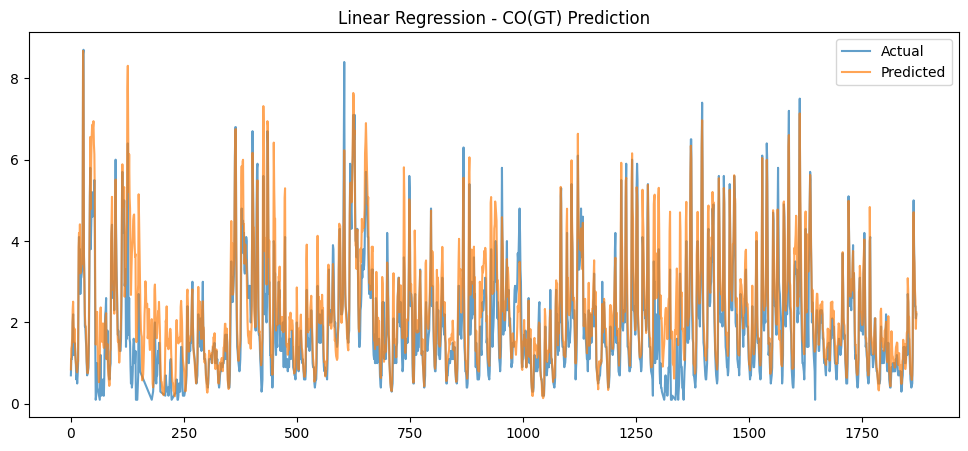

In [ ]:
# ===========================================
# Step 1: Import libraries
# ===========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===========================================
# Step 2: Load dataset
# (Upload your CSV file in Colab: left sidebar > Files > Upload)
# ===========================================
file_path = "/content/AirQuality.csv"
df = pd.read_csv(file_path, sep=";")

# ===========================================
# Step 3: Clean data
# - Replace commas with dots in decimals
# - Drop unnamed columns
# ===========================================
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

for c in df.columns:
    df[c] = df[c].astype(str).str.replace(",", ".", regex=False)

# Create datetime column (known format: DD/MM/YYYY HH.MM.SS)
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"   # invalid -> NaT
)

# Drop rows with invalid datetime
df = df.dropna(subset=["datetime"])
df = df.drop(columns=["Date", "Time"])
df = df.sort_values("datetime").reset_index(drop=True)

# Convert all remaining columns to numeric
for c in df.columns:
    if c != "datetime":
        df[c] = pd.to_numeric(df[c], errors="coerce")

# ===========================================
# Step 4: Handle missing values
# ===========================================
df = df.set_index("datetime")
df = df.replace(-200, np.nan)
df = df.interpolate(method="time").fillna(df.median())
df = df.reset_index()

# ===========================================
# Step 5: Select features and target
# ===========================================
target = "CO(GT)"
features = df.drop(columns=[target, "datetime"]).columns

X = df[features]
y = df[target]

# Drop rows with NaN in target
mask = ~y.isna()
X, y = X[mask], y[mask]

# ===========================================
# Step 6: Train/test split (time-based: first 80% train, last 20% test)
# ===========================================
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ===========================================
# Step 7: Train Linear Regression
# ===========================================
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# ===========================================
# Step 8: Evaluate
# ===========================================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

# ===========================================
# Step 9: Plot actual vs predicted
# ===========================================
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual", alpha=0.7)
plt.plot(y_pred, label="Predicted", alpha=0.7)
plt.title("Linear Regression - CO(GT) Prediction")
plt.legend()
plt.show()


Decision Tree Results:
MAE:  0.599
RMSE: 0.807
R²:   0.658


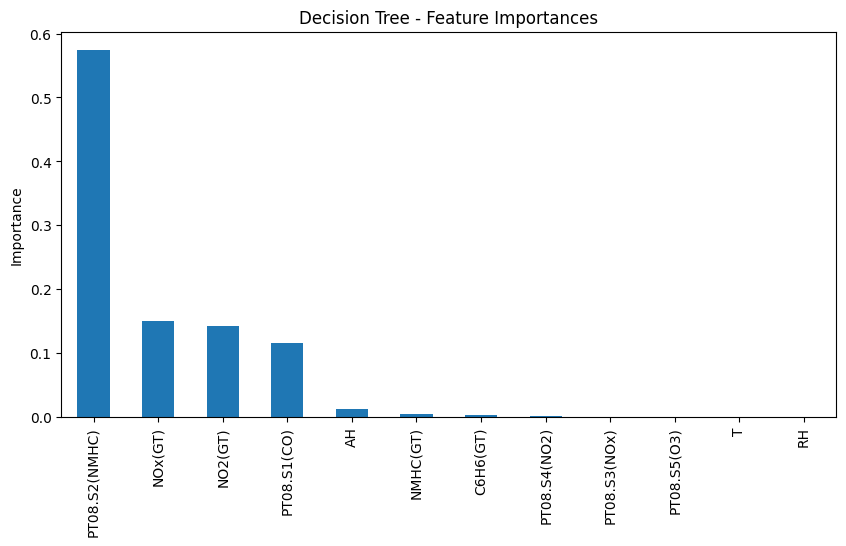

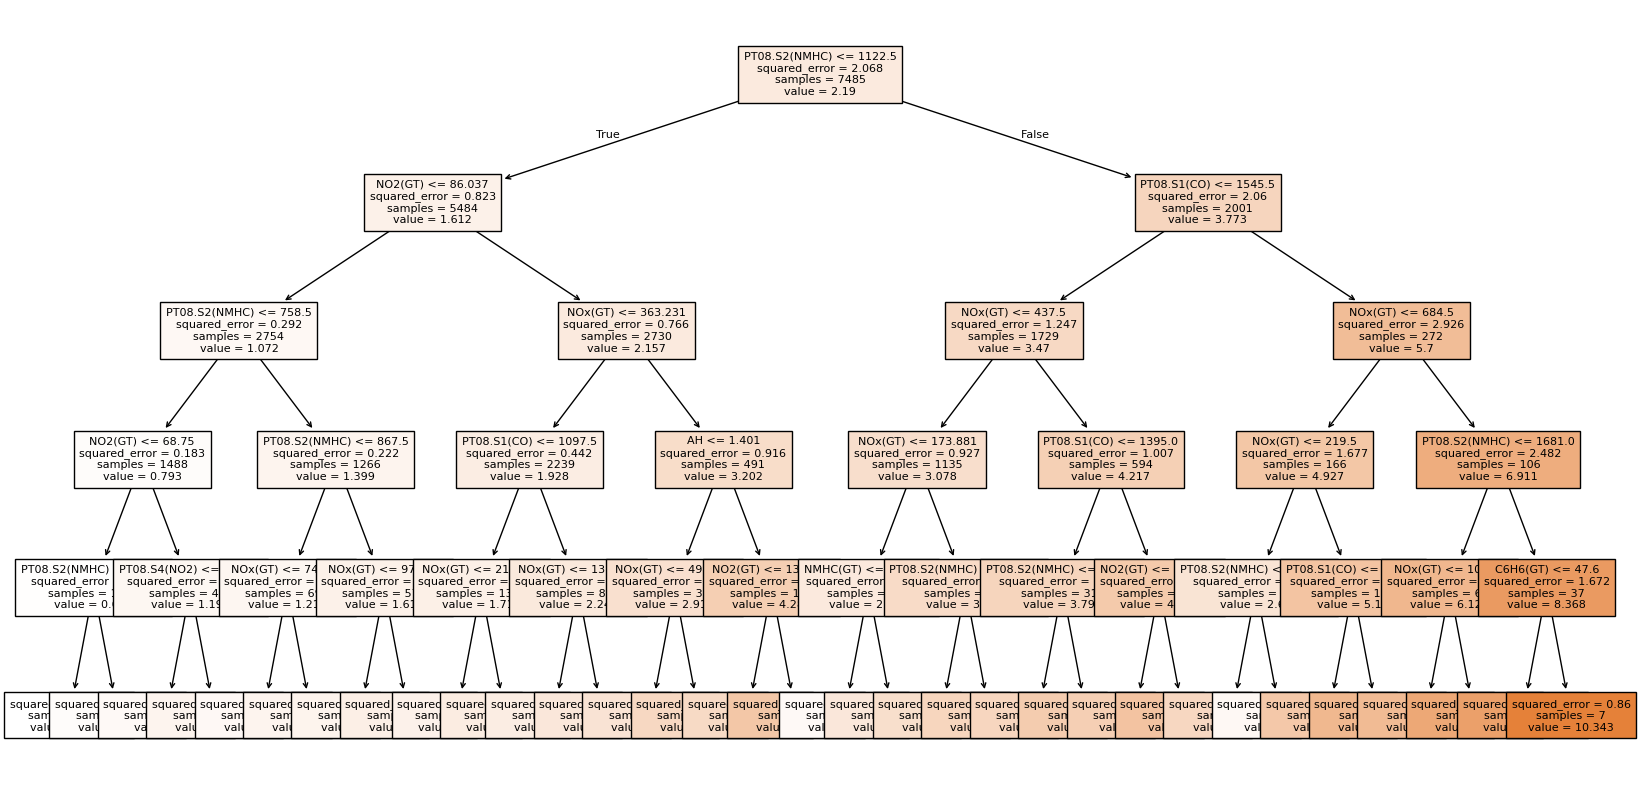

In [ ]:
# ===========================================
# Step 1: Import libraries
# ===========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===========================================
# Step 2: Load dataset
# ===========================================
file_path = "/content/AirQuality.csv"
df = pd.read_csv(file_path, sep=";")

# ===========================================
# Step 3: Data Cleaning
# ===========================================
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# replace commas in decimals
for c in df.columns:
    df[c] = df[c].astype(str).str.replace(",", ".", regex=False)

# parse datetime
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)
df = df.dropna(subset=["datetime"])
df = df.drop(columns=["Date", "Time"])
df = df.sort_values("datetime").reset_index(drop=True)

# convert columns to numeric
for c in df.columns:
    if c != "datetime":
        df[c] = pd.to_numeric(df[c], errors="coerce")

# handle missing values
df = df.set_index("datetime")
df = df.replace(-200, np.nan)
df = df.interpolate(method="time").fillna(df.median())
df = df.reset_index()

# ===========================================
# Step 4: Features & Target
# ===========================================
target = "CO(GT)"
features = df.drop(columns=[target, "datetime"]).columns

X = df[features]
y = df[target]

mask = ~y.isna()
X, y = X[mask], y[mask]

# split (80% train, 20% test, time-based)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ===========================================
# Step 5: Train Decision Tree
# ===========================================
dt = DecisionTreeRegressor(
    max_depth=5,   # limit depth for interpretability
    random_state=42
)
dt.fit(X_train, y_train)

# predictions
y_pred = dt.predict(X_test)

# ===========================================
# Step 6: Evaluation
# ===========================================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Decision Tree Results:")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

# ===========================================
# Step 7: Feature Importance
# ===========================================
importances = pd.Series(dt.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,5))
importances.plot(kind="bar")
plt.title("Decision Tree - Feature Importances")
plt.ylabel("Importance")
plt.show()

# ===========================================
# Step 8: Visualize Tree (simplified view)
# ===========================================
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=features, filled=True, fontsize=8)
plt.show()


Random Forest Results:
MAE:  0.423
RMSE: 0.652
R²:   0.777


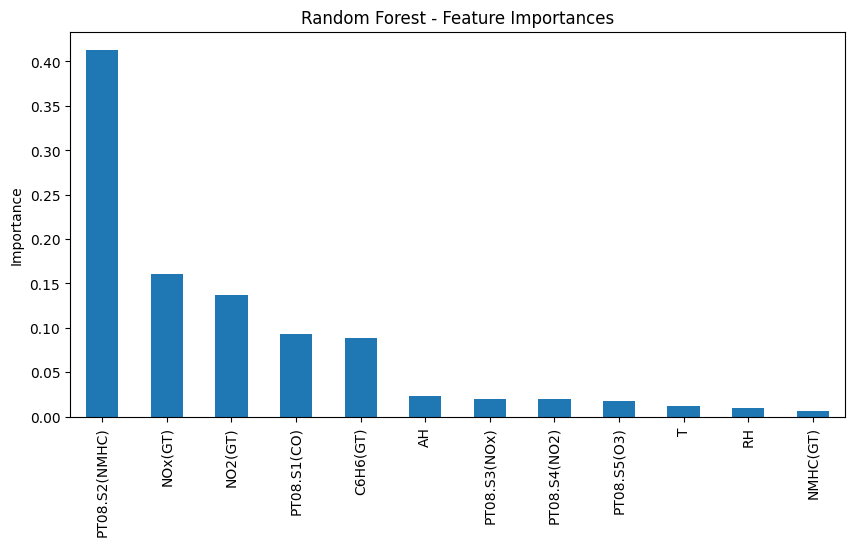

In [ ]:
# ===========================================
# Step 1: Import libraries
# ===========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===========================================
# Step 2: Load dataset
# ===========================================
file_path = "/content/AirQuality.csv"
df = pd.read_csv(file_path, sep=";")

# ===========================================
# Step 3: Data Cleaning
# ===========================================
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# replace commas in decimals
for c in df.columns:
    df[c] = df[c].astype(str).str.replace(",", ".", regex=False)

# parse datetime
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)
df = df.dropna(subset=["datetime"])
df = df.drop(columns=["Date", "Time"])
df = df.sort_values("datetime").reset_index(drop=True)

# convert columns to numeric
for c in df.columns:
    if c != "datetime":
        df[c] = pd.to_numeric(df[c], errors="coerce")

# handle missing values
df = df.set_index("datetime")
df = df.replace(-200, np.nan)
df = df.interpolate(method="time").fillna(df.median())
df = df.reset_index()

# ===========================================
# Step 4: Features & Target
# ===========================================
target = "CO(GT)"
features = df.drop(columns=[target, "datetime"]).columns

X = df[features]
y = df[target]

mask = ~y.isna()
X, y = X[mask], y[mask]

# split (80% train, 20% test, time-based)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ===========================================
# Step 5: Train Random Forest
# ===========================================
rf = RandomForestRegressor(
    n_estimators=100,   # number of trees
    max_depth=None,     # let trees grow fully
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# predictions
y_pred = rf.predict(X_test)

# ===========================================
# Step 6: Evaluation
# ===========================================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Results:")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

# ===========================================
# Step 7: Feature Importance
# ===========================================
importances = pd.Series(rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,5))
importances.plot(kind="bar")
plt.title("Random Forest - Feature Importances")
plt.ylabel("Importance")
plt.show()


XGBoost Results:
MAE:  0.473
RMSE: 0.696
R²:   0.746


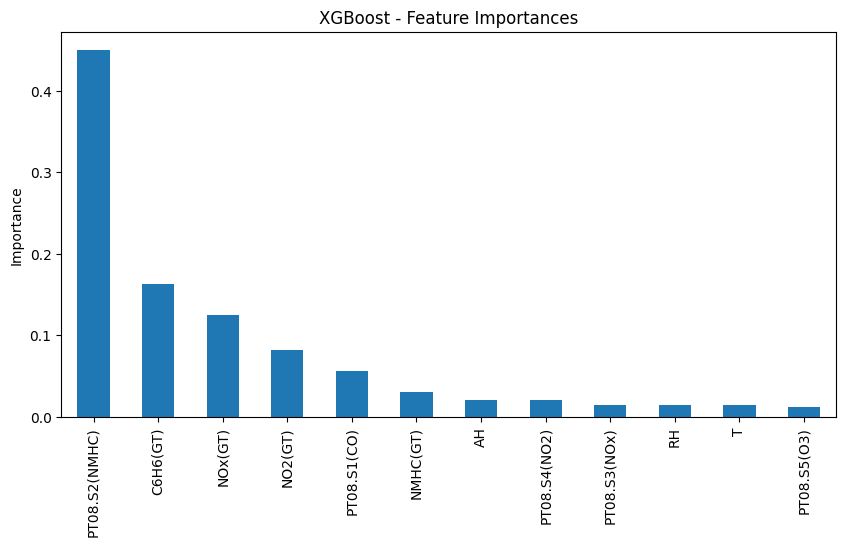

 99%|===================| 1844/1872 [01:11<00:01]       

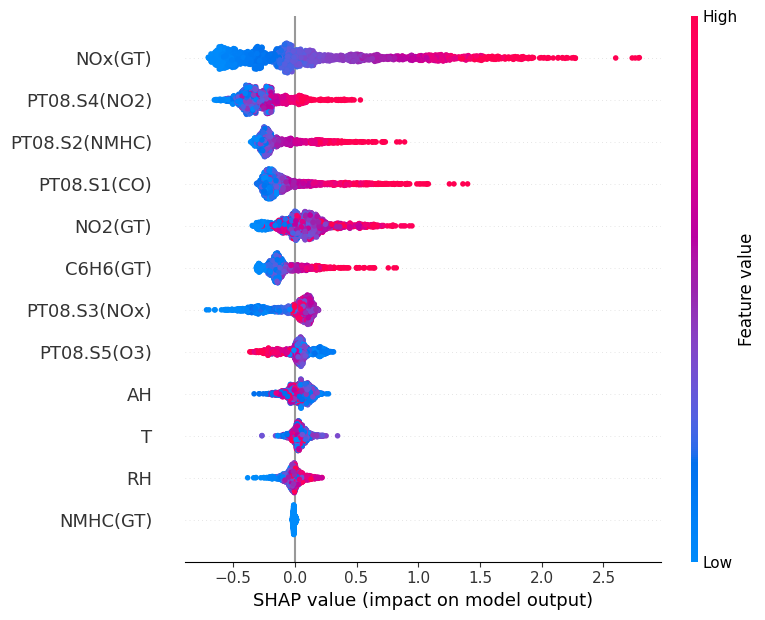

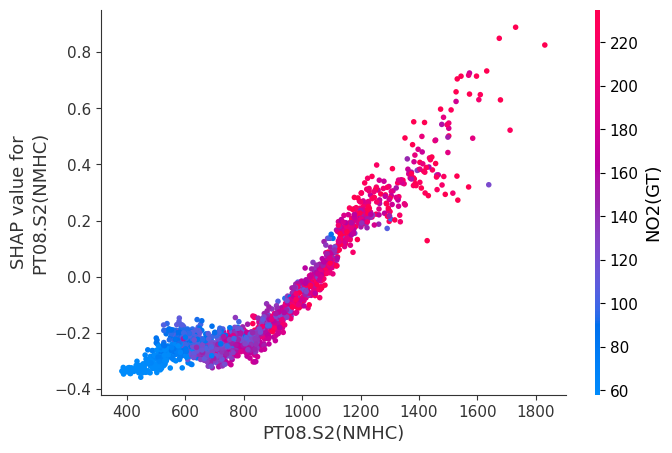

In [ ]:
# ===========================================
# Step 1: Install required libraries (Colab only)
# ===========================================
!pip install xgboost shap --quiet

# ===========================================
# Step 2: Import libraries
# ===========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

# ===========================================
# Step 3: Load dataset
# ===========================================
file_path = "/content/AirQuality.csv"
df = pd.read_csv(file_path, sep=";")

# ===========================================
# Step 4: Data Cleaning
# ===========================================
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# replace commas in decimals
for c in df.columns:
    df[c] = df[c].astype(str).str.replace(",", ".", regex=False)

# parse datetime
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)
df = df.dropna(subset=["datetime"])
df = df.drop(columns=["Date", "Time"])
df = df.sort_values("datetime").reset_index(drop=True)

# convert columns to numeric
for c in df.columns:
    if c != "datetime":
        df[c] = pd.to_numeric(df[c], errors="coerce")

# handle missing values
df = df.set_index("datetime")
df = df.replace(-200, np.nan)
df = df.interpolate(method="time").fillna(df.median())
df = df.reset_index()

# ===========================================
# Step 5: Features & Target
# ===========================================
target = "CO(GT)"
features = df.drop(columns=[target, "datetime"]).columns

X = df[features]
y = df[target]

mask = ~y.isna()
X, y = X[mask], y[mask]

# split (80% train, 20% test, time-based)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ===========================================
# Step 6: Train Gradient Boosting (XGBoost)
# ===========================================
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

# predictions
y_pred = xgb.predict(X_test)

# ===========================================
# Step 7: Evaluation
# ===========================================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBoost Results:")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

# ===========================================
# Step 8: Feature Importance
# ===========================================
importances = pd.Series(xgb.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,5))
importances.plot(kind="bar")
plt.title("XGBoost - Feature Importances")
plt.ylabel("Importance")
plt.show()

# ===========================================
# Step 9: SHAP Explainability
# ===========================================
# Initialize SHAP explainer
explainer = shap.Explainer(xgb, X_train)

# Compute SHAP values
shap_values = explainer(X_test)

# Summary plot (global feature importance)
shap.summary_plot(shap_values, X_test)

# Dependence plot for top feature
top_feature = importances.index[0]
shap.dependence_plot(top_feature, shap_values.values, X_test)


Shape of dataset: (9471, 17)
Columns: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']


INFO:PyALE._ALE_generic:Continuous feature detected.


Root Mean Squared Error (RMSE): 0.4668913911864458

Generating 1D ALE plots...


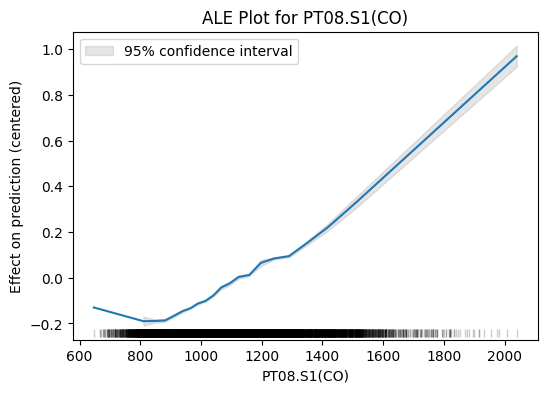

INFO:PyALE._ALE_generic:Continuous feature detected.


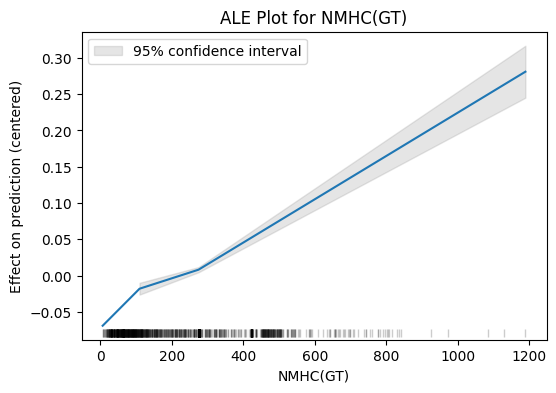

INFO:PyALE._ALE_generic:Continuous feature detected.


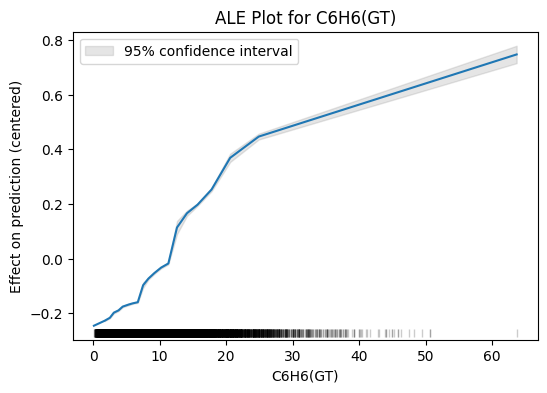

INFO:PyALE._ALE_generic:Continuous feature detected.


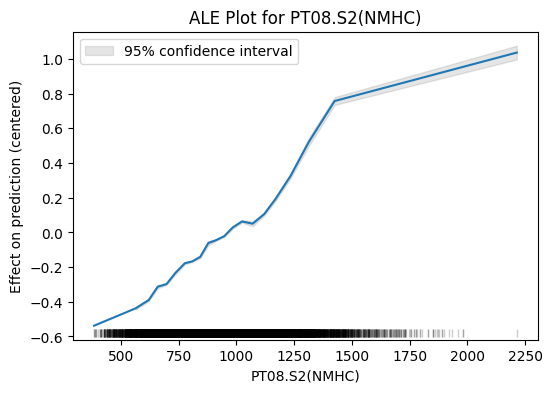

INFO:PyALE._ALE_generic:Continuous feature detected.


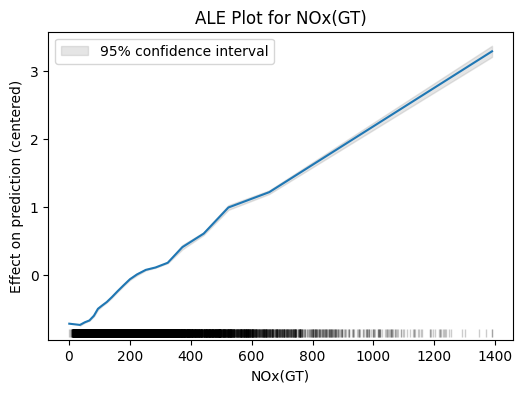


Generating 2D ALE plot...


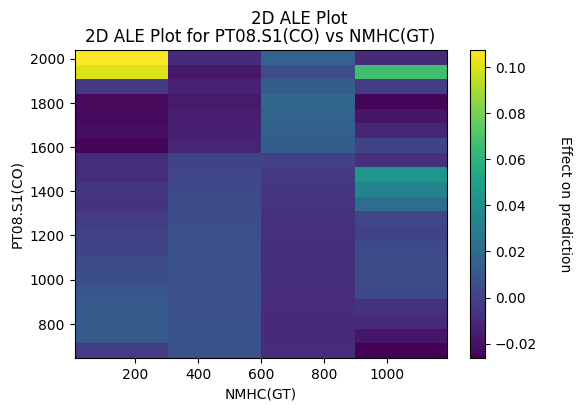

In [ ]:
# --- ALE Model for AirQuality.csv ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Install ALE package if not installed
!pip install PyALE --quiet

from PyALE import ale

# -------------------------------
# Step 1: Load Dataset
# -------------------------------
file_path = "/content/AirQuality.csv"
df = pd.read_csv(file_path, sep=";")

print("Shape of dataset:", df.shape)
print("Columns:", list(df.columns))

# -------------------------------
# Step 2: Data Preprocessing
# -------------------------------
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# replace commas with decimals
for c in df.columns:
    df[c] = df[c].astype(str).str.replace(",", ".", regex=False)

# parse datetime
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)
df = df.dropna(subset=["datetime"])
df = df.drop(columns=["Date", "Time"])
df = df.sort_values("datetime").reset_index(drop=True)

# handle explicit non-numeric strings that represent missing values
df = df.replace(['nan', 'NaN', ''], np.nan)


# convert columns to numeric, excluding datetime
numeric_cols = df.columns.drop("datetime")
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")


# handle missing values (-200, interpolate, fillna)
df = df.set_index("datetime")
df = df.replace(-200, np.nan)
df = df.interpolate(method="time").fillna(df.median())
df = df.reset_index()

# -------------------------------
# Step 3: Features & Target
# -------------------------------
target_col = "CO(GT)" # Correct target variable for this dataset
features = df.drop(columns=[target_col, "datetime"]).columns

X = df[features]
y = df[target_col]

# Drop rows with NaN in target before splitting
mask = ~y.isna()
X, y = X[mask], y[mask]


# -------------------------------
# Step 4: Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Step 5: Train Random Forest Model
# -------------------------------
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Model evaluation
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", rmse)

# -------------------------------
# Step 6: 1D ALE Plots (Feature Effects)
# -------------------------------
print("\nGenerating 1D ALE plots...")

for feature in X_train.columns[:5]:  # First 5 features for demo
    fig, ax = plt.subplots(figsize=(6, 4))
    ale(
        X=X_train,
        model=model,
        feature=[feature],
        grid_size=20,
        include_CI=True,
        fig=fig,
        ax=ax
    )
    plt.title(f"ALE Plot for {feature}")
    plt.show()

# -------------------------------
# Step 7: 2D ALE Plots (Feature Interactions)
# -------------------------------
print("\nGenerating 2D ALE plot...")

# Example: interaction between first two features
if len(X_train.columns) >= 2:
    fig, ax = plt.subplots(figsize=(6, 4))
    ale(
        X=X_train,
        model=model,
        feature=[X_train.columns[0], X_train.columns[1]],
        grid_size=20,
        fig=fig,
        ax=ax
    )
    plt.title(f"2D ALE Plot for {X_train.columns[0]} vs {X_train.columns[1]}")
    plt.show()

🔄 COMPREHENSIVE PERMUTATION ANALYSIS - AIR QUALITY DATASET

📂 Step 1: Loading and Preprocessing Data
--------------------------------------------------
Original dataset shape: (9471, 17)
Columns: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']
Processed dataset shape: (9357, 14)
Missing values: 0

🎯 Step 2: Feature Engineering and Target Selection
--------------------------------------------------
Features: 12 columns
Samples: 9357 rows
Regression target: CO(GT)
Classification target: CO_category
Class distribution:
CO_category
Low       3182
High      3119
Medium    3056
Name: count, dtype: int64

🔍 Step 3: Permutation Feature Importance Analysis
--------------------------------------------------
🔢 Regression Permutation Importance...
📊 Classification Permutation Importance...

📈 Step 4: Visualizing Permutation Importance
--------------

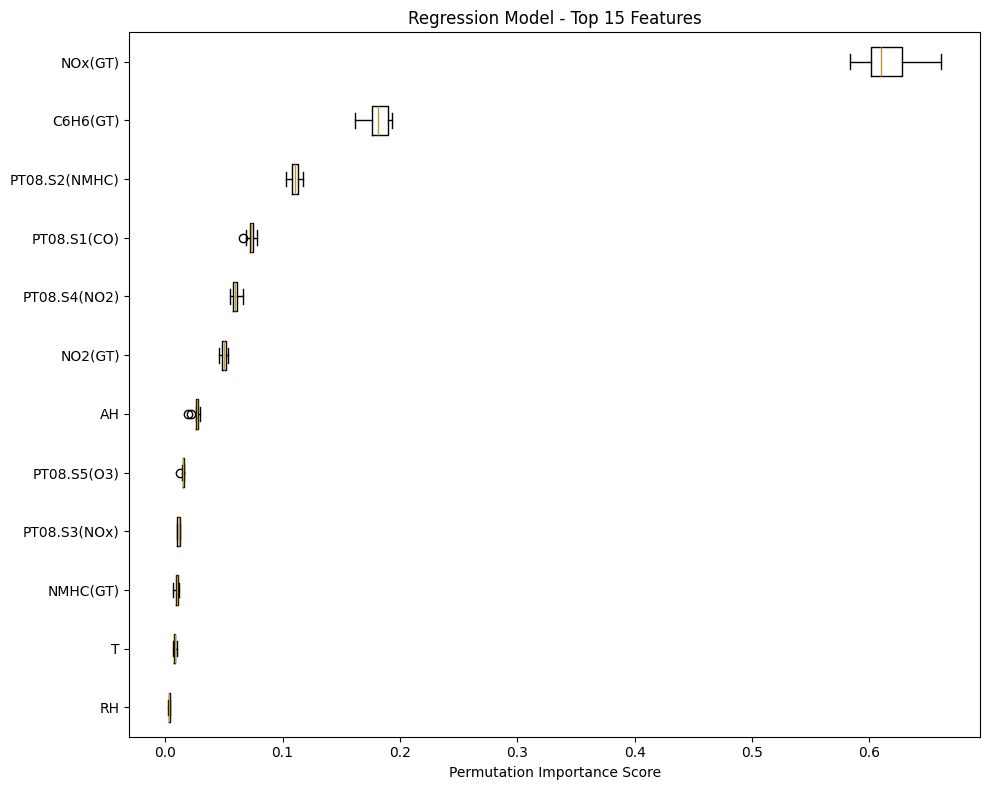


🏆 Top 10 Most Important Features for Regression Model:
   1. NOx(GT)             : 0.6144 (±0.0229)
   2. C6H6(GT)            : 0.1815 (±0.0093)
   3. PT08.S2(NMHC)       : 0.1107 (±0.0043)
   4. PT08.S1(CO)         : 0.0729 (±0.0033)
   5. PT08.S4(NO2)        : 0.0599 (±0.0031)
   6. NO2(GT)             : 0.0499 (±0.0027)
   7. AH                  : 0.0264 (±0.0030)
   8. PT08.S5(O3)         : 0.0153 (±0.0011)
   9. PT08.S3(NOx)        : 0.0115 (±0.0011)
  10. NMHC(GT)            : 0.0099 (±0.0016)


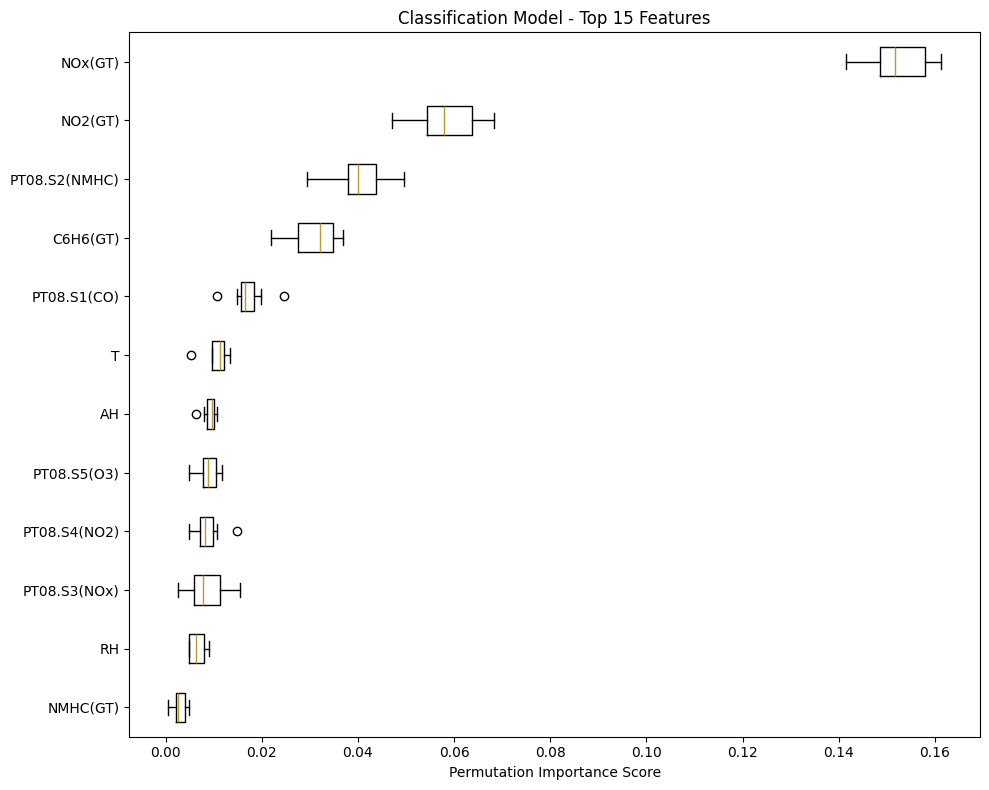


🏆 Top 10 Most Important Features for Classification Model:
   1. NOx(GT)             : 0.1526 (±0.0060)
   2. NO2(GT)             : 0.0584 (±0.0064)
   3. PT08.S2(NMHC)       : 0.0396 (±0.0060)
   4. C6H6(GT)            : 0.0308 (±0.0050)
   5. PT08.S1(CO)         : 0.0171 (±0.0034)
   6. T                   : 0.0107 (±0.0022)
   7. AH                  : 0.0093 (±0.0013)
   8. PT08.S5(O3)         : 0.0090 (±0.0020)
   9. PT08.S4(NO2)        : 0.0087 (±0.0028)
  10. PT08.S3(NOx)        : 0.0084 (±0.0036)

🧪 Step 5: Permutation Test for Model Significance
--------------------------------------------------
🔢 Testing Regression Model Significance...
  True R² Score: 0.8865
  Permutation Scores Mean: -0.0882 (±0.0086)
  P-value: 0.0099
  Model is SIGNIFICANT (p < 0.05)

📊 Testing Classification Model Significance...
  True Accuracy Score: 0.8641
  Permutation Scores Mean: 0.3320 (±0.0065)
  P-value: 0.0099
  Model is SIGNIFICANT (p < 0.05)

🔄 Step 6: Feature Combination Permutation Analysi

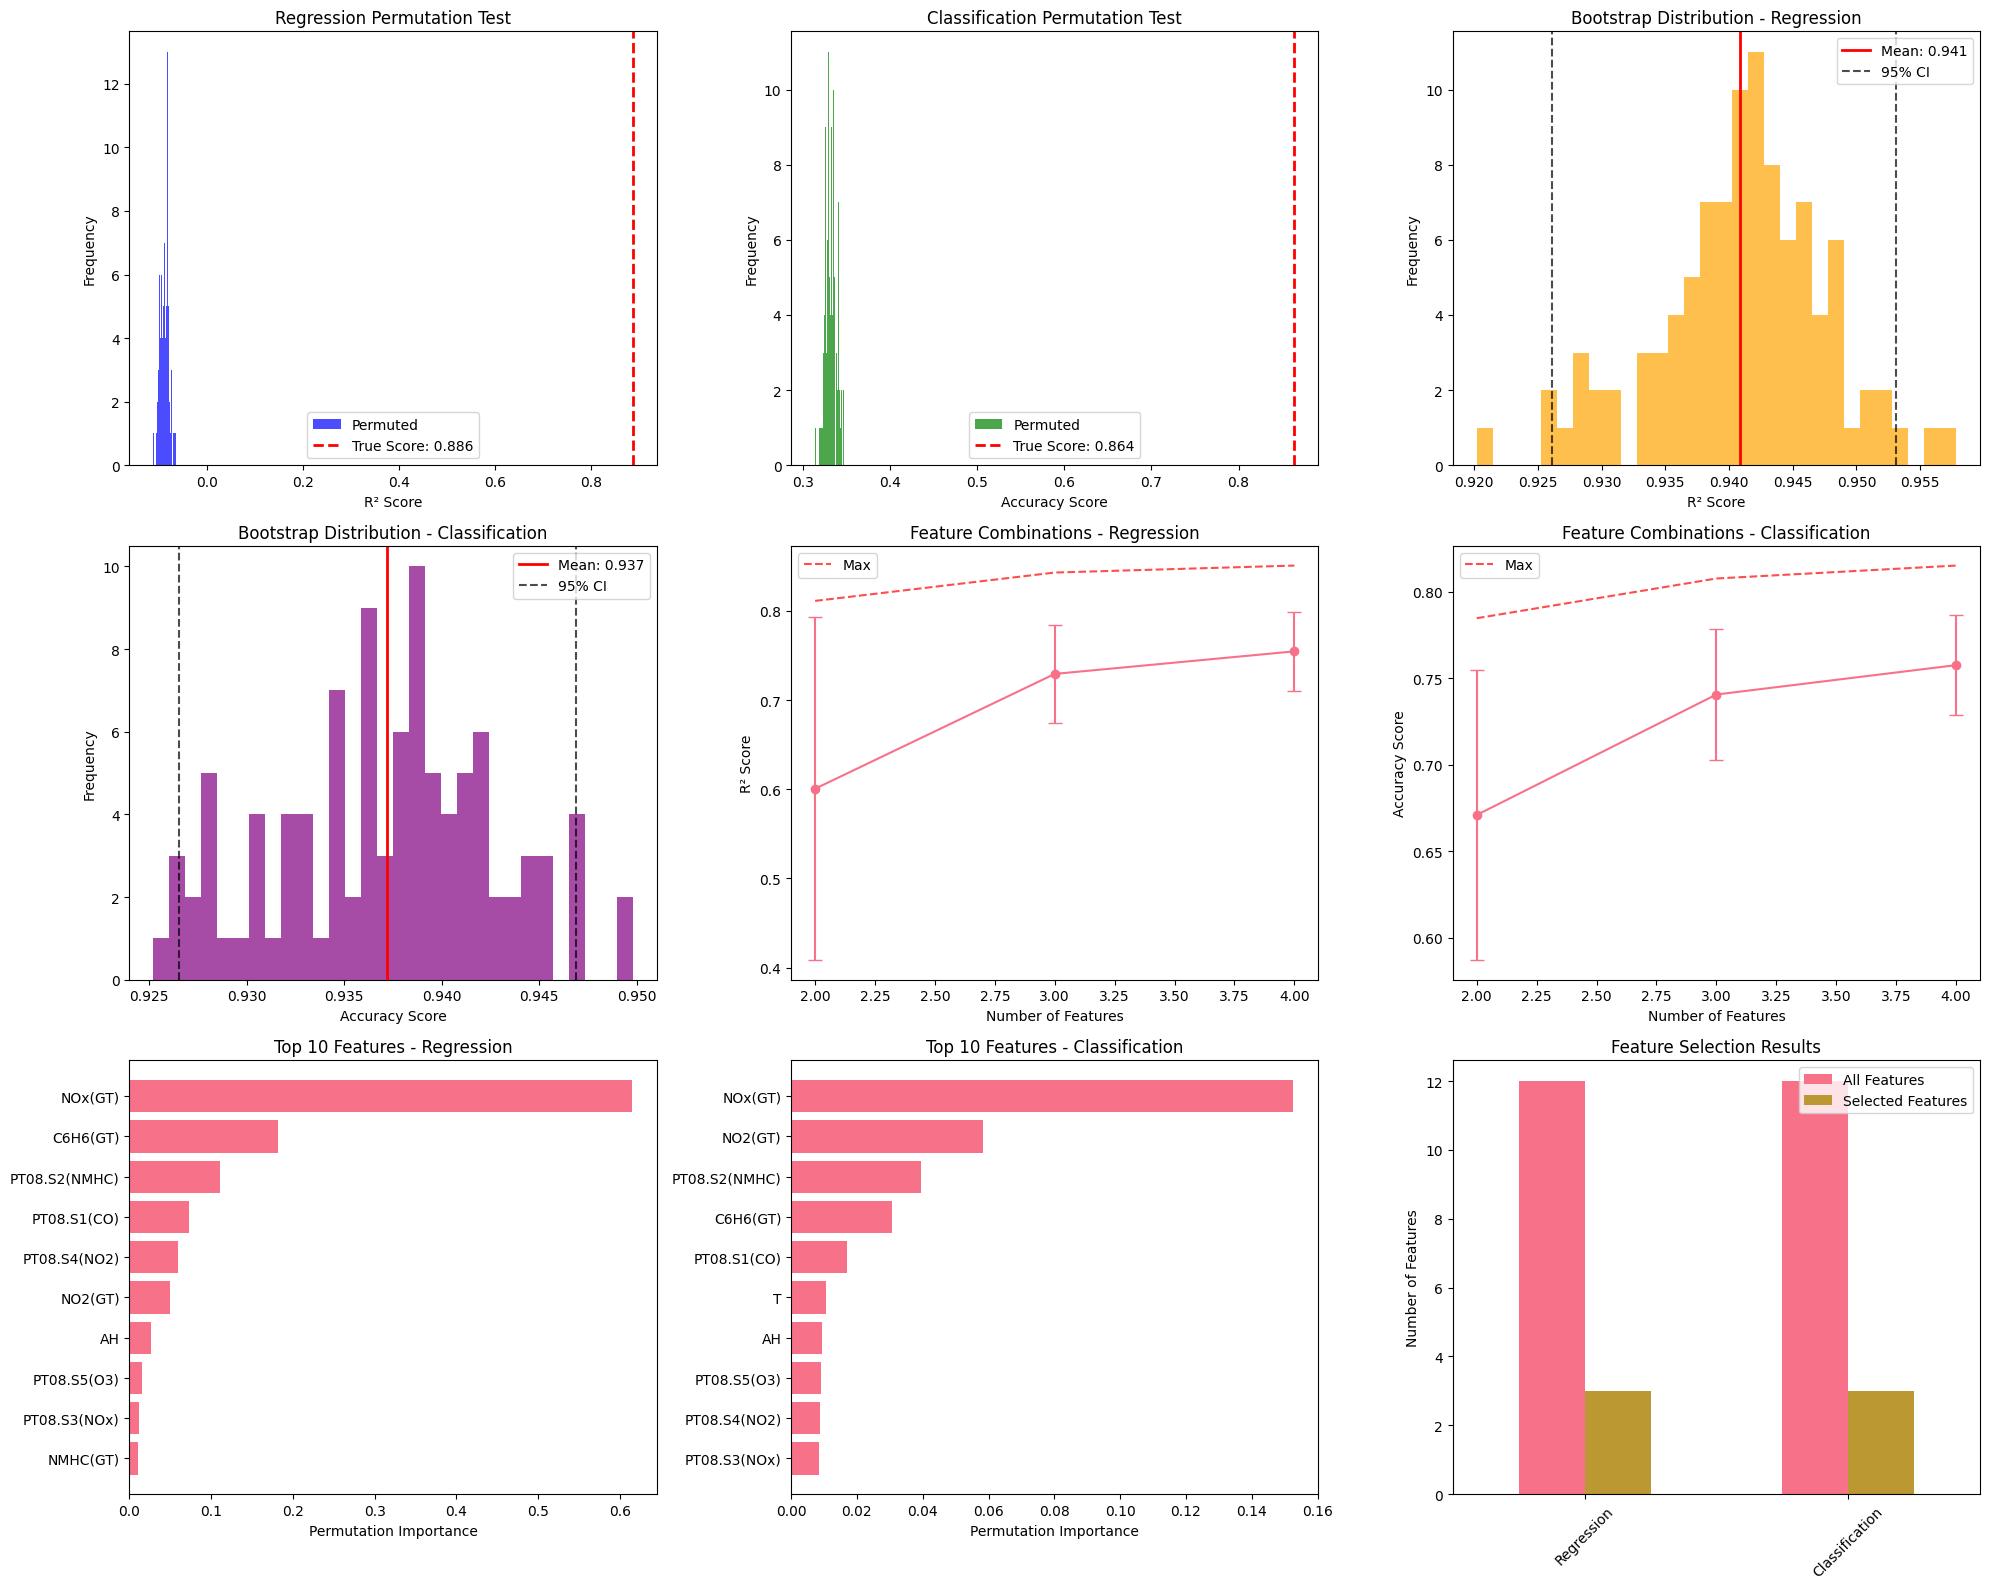


📋 FINAL PERMUTATION ANALYSIS SUMMARY REPORT

📊 DATASET OVERVIEW:
  • Total samples: 9,357
  • Total features: 12
  • Regression target: CO(GT)
  • Classification target: CO_category

🎯 MODEL PERFORMANCE:
  • Regression R² Score: 0.8865 (p=0.0099)
  • Classification Accuracy: 0.8641 (p=0.0099)
  • Both models are SIGNIFICANT

🔍 BOOTSTRAP CONFIDENCE INTERVALS:
  • Regression R² 95% CI: [0.9261, 0.9531]
  • Classification Accuracy 95% CI: [0.9265, 0.9469]

🎯 FEATURE SELECTION RESULTS:
  • Regression: 3/12 features selected
  • Classification: 3/12 features selected

🏆 TOP 5 MOST IMPORTANT FEATURES:
  Regression:
    1. NOx(GT): 0.6144
    2. C6H6(GT): 0.1815
    3. PT08.S2(NMHC): 0.1107
    4. PT08.S1(CO): 0.0729
    5. PT08.S4(NO2): 0.0599
  Classification:
    1. NOx(GT): 0.1526
    2. NO2(GT): 0.0584
    3. PT08.S2(NMHC): 0.0396
    4. C6H6(GT): 0.0308
    5. PT08.S1(CO): 0.0171

📈 BEST FEATURE COMBINATIONS:
  • Best regression combo (4 features): R² = 0.8508
    Features: PT08.S1(CO)

In [ ]:
# === COMPLETE PERMUTATION ANALYSIS FOR AIR QUALITY DATASET ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, permutation_test_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, classification_report, confusion_matrix
)

# Statistical tests
from scipy.stats import permutation_test, bootstrap
from itertools import permutations, combinations

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

print("="*80)
print("🔄 COMPREHENSIVE PERMUTATION ANALYSIS - AIR QUALITY DATASET")
print("="*80)

# -------------------------------
# STEP 1: DATA LOADING & PREPROCESSING
# -------------------------------
print("\n📂 Step 1: Loading and Preprocessing Data")
print("-" * 50)

file_path = "/content/AirQuality.csv"
df = pd.read_csv(file_path, sep=";")

print(f"Original dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Remove unnamed columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Replace commas with decimals
for c in df.columns:
    df[c] = df[c].astype(str).str.replace(",", ".", regex=False)

# Parse datetime
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)
df = df.dropna(subset=["datetime"])
df = df.drop(columns=["Date", "Time"])
df = df.sort_values("datetime").reset_index(drop=True)

# Handle missing values
df = df.replace(['nan', 'NaN', ''], np.nan)

# Convert to numeric
numeric_cols = df.columns.drop("datetime")
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Handle missing values (-200, interpolate, fillna)
df = df.set_index("datetime")
df = df.replace(-200, np.nan)
df = df.interpolate(method="time").fillna(df.median())
df = df.reset_index()

print(f"Processed dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

# -------------------------------
# STEP 2: FEATURE ENGINEERING & TARGET SELECTION
# -------------------------------
print("\n🎯 Step 2: Feature Engineering and Target Selection")
print("-" * 50)

# Define targets for different analysis
regression_target = "CO(GT)"
classification_target = "CO_category"

# Create classification target (Low, Medium, High CO levels)
co_values = df[regression_target]
co_terciles = np.percentile(co_values, [33.33, 66.67])
df[classification_target] = pd.cut(
    co_values,
    bins=[-np.inf, co_terciles[0], co_terciles[1], np.inf],
    labels=['Low', 'Medium', 'High']
)

# Feature selection
feature_cols = df.drop(columns=[regression_target, classification_target, "datetime"]).columns
X = df[feature_cols]
y_reg = df[regression_target]
y_cls = df[classification_target]

# Remove rows with NaN targets
mask = ~(y_reg.isna() | y_cls.isna())
X, y_reg, y_cls = X[mask], y_reg[mask], y_cls[mask]

print(f"Features: {len(feature_cols)} columns")
print(f"Samples: {len(X)} rows")
print(f"Regression target: {regression_target}")
print(f"Classification target: {classification_target}")
print(f"Class distribution:\n{y_cls.value_counts()}")

# -------------------------------
# STEP 3: PERMUTATION FEATURE IMPORTANCE
# -------------------------------
print("\n🔍 Step 3: Permutation Feature Importance Analysis")
print("-" * 50)

def calculate_permutation_importance(X, y, model, task_type='regression', n_repeats=10):
    """Calculate permutation importance for features"""

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y if task_type=='classification' else None
    )

    # Fit model
    model.fit(X_train, y_train)

    # Calculate permutation importance
    perm_importance = permutation_importance(
        model, X_test, y_test,
        n_repeats=n_repeats,
        random_state=42,
        scoring='r2' if task_type=='regression' else 'accuracy'
    )

    return perm_importance, X_test, y_test, model

# Regression Permutation Importance
print("🔢 Regression Permutation Importance...")
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
perm_imp_reg, X_test_reg, y_test_reg, model_reg = calculate_permutation_importance(
    X, y_reg, rf_reg, 'regression'
)

# Classification Permutation Importance
print("📊 Classification Permutation Importance...")
rf_cls = RandomForestClassifier(n_estimators=100, random_state=42)
perm_imp_cls, X_test_cls, y_test_cls, model_cls = calculate_permutation_importance(
    X, y_cls, rf_cls, 'classification'
)

# -------------------------------
# STEP 4: VISUALIZATION OF PERMUTATION IMPORTANCE
# -------------------------------
print("\n📈 Step 4: Visualizing Permutation Importance")
print("-" * 50)

def plot_permutation_importance(perm_importance, feature_names, title, top_n=15):
    """Plot permutation importance results"""

    # Sort features by importance
    sorted_idx = perm_importance.importances_mean.argsort()[-top_n:]

    fig, ax = plt.subplots(figsize=(10, 8))

    # Create box plot
    ax.boxplot([perm_importance.importances[i] for i in sorted_idx],
               vert=False, labels=[feature_names[i] for i in sorted_idx])

    ax.set_xlabel("Permutation Importance Score")
    ax.set_title(f"{title} - Top {top_n} Features")
    plt.tight_layout()
    plt.show()

    # Print top features
    print(f"\n🏆 Top {min(10, top_n)} Most Important Features for {title}:")
    for i, idx in enumerate(sorted_idx[-10:][::-1]):
        importance_mean = perm_importance.importances_mean[idx]
        importance_std = perm_importance.importances_std[idx]
        print(f"  {i+1:2d}. {feature_names[idx]:<20}: {importance_mean:.4f} (±{importance_std:.4f})")

# Plot regression importance
plot_permutation_importance(perm_imp_reg, feature_cols, "Regression Model")

# Plot classification importance
plot_permutation_importance(perm_imp_cls, feature_cols, "Classification Model")

# -------------------------------
# STEP 5: PERMUTATION TEST FOR MODEL SIGNIFICANCE
# -------------------------------
print("\n🧪 Step 5: Permutation Test for Model Significance")
print("-" * 50)

def permutation_test_model(X, y, model, task_type='regression', n_permutations=100):
    """Perform permutation test to assess model significance"""

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y if task_type=='classification' else None
    )

    # Define scoring function
    scoring = 'r2' if task_type == 'regression' else 'accuracy'

    # Perform permutation test
    score, perm_scores, pvalue = permutation_test_score(
        model, X_train, y_train,
        scoring=scoring,
        cv=5,
        n_permutations=n_permutations,
        random_state=42
    )

    return score, perm_scores, pvalue

# Regression permutation test
print("🔢 Testing Regression Model Significance...")
reg_score, reg_perm_scores, reg_pvalue = permutation_test_model(
    X, y_reg, RandomForestRegressor(n_estimators=50, random_state=42), 'regression'
)

print(f"  True R² Score: {reg_score:.4f}")
print(f"  Permutation Scores Mean: {np.mean(reg_perm_scores):.4f} (±{np.std(reg_perm_scores):.4f})")
print(f"  P-value: {reg_pvalue:.4f}")
print(f"  Model is {'SIGNIFICANT' if reg_pvalue < 0.05 else 'NOT SIGNIFICANT'} (p < 0.05)")

# Classification permutation test
print("\n📊 Testing Classification Model Significance...")
cls_score, cls_perm_scores, cls_pvalue = permutation_test_model(
    X, y_cls, RandomForestClassifier(n_estimators=50, random_state=42), 'classification'
)

print(f"  True Accuracy Score: {cls_score:.4f}")
print(f"  Permutation Scores Mean: {np.mean(cls_perm_scores):.4f} (±{np.std(cls_perm_scores):.4f})")
print(f"  P-value: {cls_pvalue:.4f}")
print(f"  Model is {'SIGNIFICANT' if cls_pvalue < 0.05 else 'NOT SIGNIFICANT'} (p < 0.05)")

# -------------------------------
# STEP 6: FEATURE PERMUTATION COMBINATIONS
# -------------------------------
print("\n🔄 Step 6: Feature Combination Permutation Analysis")
print("-" * 50)

def test_feature_combinations(X, y, model, task_type='regression', max_features=5):
    """Test different feature combinations using permutations"""

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y if task_type=='classification' else None
    )

    results = []
    feature_names = X.columns.tolist()

    # Test combinations of 2 to max_features
    for n_features in range(2, min(max_features + 1, len(feature_names) + 1)):
        print(f"  Testing {n_features}-feature combinations...")

        # Get top combinations (limit to avoid exponential explosion)
        n_combinations = min(50, len(list(combinations(feature_names, n_features))))

        for i, feature_combo in enumerate(combinations(feature_names, n_features)):
            if i >= n_combinations:
                break

            X_subset = X_train[list(feature_combo)]
            X_test_subset = X_test[list(feature_combo)]

            model.fit(X_subset, y_train)

            if task_type == 'regression':
                y_pred = model.predict(X_test_subset)
                score = r2_score(y_test, y_pred)
            else:
                y_pred = model.predict(X_test_subset)
                score = accuracy_score(y_test, y_pred)

            results.append({
                'n_features': n_features,
                'features': feature_combo,
                'score': score
            })

    return pd.DataFrame(results)

# Test regression combinations
print("🔢 Testing Regression Feature Combinations...")
reg_combo_results = test_feature_combinations(
    X, y_reg, RandomForestRegressor(n_estimators=50, random_state=42), 'regression', 4
)

# Test classification combinations
print("📊 Testing Classification Feature Combinations...")
cls_combo_results = test_feature_combinations(
    X, y_cls, RandomForestClassifier(n_estimators=50, random_state=42), 'classification', 4
)

# -------------------------------
# STEP 7: BOOTSTRAP PERMUTATION CONFIDENCE INTERVALS
# -------------------------------
print("\n🎲 Step 7: Bootstrap Permutation Confidence Intervals")
print("-" * 50)

def bootstrap_permutation_ci(X, y, model, task_type='regression', n_bootstrap=100):
    """Calculate confidence intervals using bootstrap permutation"""

    def score_function(X, y, model, task_type):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=None, stratify=y if task_type=='classification' else None
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        if task_type == 'regression':
            return r2_score(y_test, y_pred)
        else:
            return accuracy_score(y_test, y_pred)

    # Bootstrap sampling
    scores = []
    n_samples = len(X)

    for i in range(n_bootstrap):
        # Bootstrap sample with replacement
        bootstrap_idx = np.random.choice(n_samples, n_samples, replace=True)
        X_boot = X.iloc[bootstrap_idx]
        y_boot = y.iloc[bootstrap_idx]

        score = score_function(X_boot, y_boot, model, task_type)
        scores.append(score)

    scores = np.array(scores)
    ci_lower = np.percentile(scores, 2.5)
    ci_upper = np.percentile(scores, 97.5)
    mean_score = np.mean(scores)

    return mean_score, ci_lower, ci_upper, scores

# Bootstrap regression
print("🔢 Bootstrap Confidence Intervals - Regression...")
reg_mean, reg_ci_low, reg_ci_high, reg_boot_scores = bootstrap_permutation_ci(
    X, y_reg, RandomForestRegressor(n_estimators=50, random_state=42), 'regression'
)

print(f"  Mean R² Score: {reg_mean:.4f}")
print(f"  95% CI: [{reg_ci_low:.4f}, {reg_ci_high:.4f}]")

# Bootstrap classification
print("📊 Bootstrap Confidence Intervals - Classification...")
cls_mean, cls_ci_low, cls_ci_high, cls_boot_scores = bootstrap_permutation_ci(
    X, y_cls, RandomForestClassifier(n_estimators=50, random_state=42), 'classification'
)

print(f"  Mean Accuracy Score: {cls_mean:.4f}")
print(f"  95% CI: [{cls_ci_low:.4f}, {cls_ci_high:.4f}]")

# -------------------------------
# STEP 8: PERMUTATION-BASED FEATURE SELECTION
# -------------------------------
print("\n🎯 Step 8: Permutation-Based Feature Selection")
print("-" * 50)

def permutation_feature_selection(X, y, model, task_type='regression', threshold_percentile=75):
    """Select features based on permutation importance threshold"""

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y if task_type=='classification' else None
    )

    model.fit(X_train, y_train)

    perm_importance = permutation_importance(
        model, X_test, y_test,
        n_repeats=10,
        random_state=42,
        scoring='r2' if task_type=='regression' else 'accuracy'
    )

    # Calculate threshold
    threshold = np.percentile(perm_importance.importances_mean, threshold_percentile)

    # Select features above threshold
    selected_features = X.columns[perm_importance.importances_mean >= threshold].tolist()

    return selected_features, perm_importance, threshold

# Feature selection for regression
print("🔢 Permutation Feature Selection - Regression...")
reg_selected_features, reg_perm_imp, reg_threshold = permutation_feature_selection(
    X, y_reg, RandomForestRegressor(n_estimators=100, random_state=42), 'regression'
)

print(f"  Threshold (75th percentile): {reg_threshold:.4f}")
print(f"  Selected {len(reg_selected_features)} features out of {len(feature_cols)}")
print(f"  Selected features: {reg_selected_features[:10]}...")  # Show first 10

# Feature selection for classification
print("📊 Permutation Feature Selection - Classification...")
cls_selected_features, cls_perm_imp, cls_threshold = permutation_feature_selection(
    X, y_cls, RandomForestClassifier(n_estimators=100, random_state=42), 'classification'
)

print(f"  Threshold (75th percentile): {cls_threshold:.4f}")
print(f"  Selected {len(cls_selected_features)} features out of {len(feature_cols)}")
print(f"  Selected features: {cls_selected_features[:10]}...")  # Show first 10

# -------------------------------
# STEP 9: COMPREHENSIVE RESULTS VISUALIZATION
# -------------------------------
print("\n📊 Step 9: Comprehensive Results Visualization")
print("-" * 50)

# Create comprehensive plots
fig = plt.figure(figsize=(20, 16))

# 1. Permutation test results
ax1 = plt.subplot(3, 3, 1)
plt.hist(reg_perm_scores, bins=30, alpha=0.7, color='blue', label='Permuted')
plt.axvline(reg_score, color='red', linestyle='--', linewidth=2, label=f'True Score: {reg_score:.3f}')
plt.xlabel('R² Score')
plt.ylabel('Frequency')
plt.title('Regression Permutation Test')
plt.legend()

ax2 = plt.subplot(3, 3, 2)
plt.hist(cls_perm_scores, bins=30, alpha=0.7, color='green', label='Permuted')
plt.axvline(cls_score, color='red', linestyle='--', linewidth=2, label=f'True Score: {cls_score:.3f}')
plt.xlabel('Accuracy Score')
plt.ylabel('Frequency')
plt.title('Classification Permutation Test')
plt.legend()

# 2. Bootstrap confidence intervals
ax3 = plt.subplot(3, 3, 3)
plt.hist(reg_boot_scores, bins=30, alpha=0.7, color='orange')
plt.axvline(reg_mean, color='red', linestyle='-', linewidth=2, label=f'Mean: {reg_mean:.3f}')
plt.axvline(reg_ci_low, color='black', linestyle='--', alpha=0.7, label=f'95% CI')
plt.axvline(reg_ci_high, color='black', linestyle='--', alpha=0.7)
plt.xlabel('R² Score')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution - Regression')
plt.legend()

ax4 = plt.subplot(3, 3, 4)
plt.hist(cls_boot_scores, bins=30, alpha=0.7, color='purple')
plt.axvline(cls_mean, color='red', linestyle='-', linewidth=2, label=f'Mean: {cls_mean:.3f}')
plt.axvline(cls_ci_low, color='black', linestyle='--', alpha=0.7, label=f'95% CI')
plt.axvline(cls_ci_high, color='black', linestyle='--', alpha=0.7)
plt.xlabel('Accuracy Score')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution - Classification')
plt.legend()

# 3. Feature combination results
ax5 = plt.subplot(3, 3, 5)
reg_combo_summary = reg_combo_results.groupby('n_features')['score'].agg(['mean', 'std', 'max'])
plt.errorbar(reg_combo_summary.index, reg_combo_summary['mean'],
             yerr=reg_combo_summary['std'], marker='o', capsize=5)
plt.plot(reg_combo_summary.index, reg_combo_summary['max'], 'r--', alpha=0.7, label='Max')
plt.xlabel('Number of Features')
plt.ylabel('R² Score')
plt.title('Feature Combinations - Regression')
plt.legend()

ax6 = plt.subplot(3, 3, 6)
cls_combo_summary = cls_combo_results.groupby('n_features')['score'].agg(['mean', 'std', 'max'])
plt.errorbar(cls_combo_summary.index, cls_combo_summary['mean'],
             yerr=cls_combo_summary['std'], marker='o', capsize=5)
plt.plot(cls_combo_summary.index, cls_combo_summary['max'], 'r--', alpha=0.7, label='Max')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy Score')
plt.title('Feature Combinations - Classification')
plt.legend()

# 4. Top feature importance comparison
ax7 = plt.subplot(3, 3, 7)
top_reg_features = np.argsort(reg_perm_imp.importances_mean)[-10:]
plt.barh(range(len(top_reg_features)), reg_perm_imp.importances_mean[top_reg_features])
plt.yticks(range(len(top_reg_features)), [feature_cols[i] for i in top_reg_features])
plt.xlabel('Permutation Importance')
plt.title('Top 10 Features - Regression')

ax8 = plt.subplot(3, 3, 8)
top_cls_features = np.argsort(cls_perm_imp.importances_mean)[-10:]
plt.barh(range(len(top_cls_features)), cls_perm_imp.importances_mean[top_cls_features])
plt.yticks(range(len(top_cls_features)), [feature_cols[i] for i in top_cls_features])
plt.xlabel('Permutation Importance')
plt.title('Top 10 Features - Classification')

# 5. Feature selection comparison
ax9 = plt.subplot(3, 3, 9)
selection_comparison = pd.DataFrame({
    'All Features': [len(feature_cols), len(feature_cols)],
    'Selected Features': [len(reg_selected_features), len(cls_selected_features)]
}, index=['Regression', 'Classification'])
selection_comparison.plot(kind='bar', ax=ax9, rot=45)
plt.title('Feature Selection Results')
plt.ylabel('Number of Features')

plt.tight_layout()
plt.show()

# -------------------------------
# STEP 10: FINAL SUMMARY REPORT
# -------------------------------
print("\n" + "="*80)
print("📋 FINAL PERMUTATION ANALYSIS SUMMARY REPORT")
print("="*80)

print(f"\n📊 DATASET OVERVIEW:")
print(f"  • Total samples: {len(X):,}")
print(f"  • Total features: {len(feature_cols)}")
print(f"  • Regression target: {regression_target}")
print(f"  • Classification target: {classification_target}")

print(f"\n🎯 MODEL PERFORMANCE:")
print(f"  • Regression R² Score: {reg_score:.4f} (p={reg_pvalue:.4f})")
print(f"  • Classification Accuracy: {cls_score:.4f} (p={cls_pvalue:.4f})")
print(f"  • Both models are {'SIGNIFICANT' if min(reg_pvalue, cls_pvalue) < 0.05 else 'NOT SIGNIFICANT'}")

print(f"\n🔍 BOOTSTRAP CONFIDENCE INTERVALS:")
print(f"  • Regression R² 95% CI: [{reg_ci_low:.4f}, {reg_ci_high:.4f}]")
print(f"  • Classification Accuracy 95% CI: [{cls_ci_low:.4f}, {cls_ci_high:.4f}]")

print(f"\n🎯 FEATURE SELECTION RESULTS:")
print(f"  • Regression: {len(reg_selected_features)}/{len(feature_cols)} features selected")
print(f"  • Classification: {len(cls_selected_features)}/{len(feature_cols)} features selected")

print(f"\n🏆 TOP 5 MOST IMPORTANT FEATURES:")
print(f"  Regression:")
top_5_reg = np.argsort(reg_perm_imp.importances_mean)[-5:][::-1]
for i, idx in enumerate(top_5_reg):
    print(f"    {i+1}. {feature_cols[idx]}: {reg_perm_imp.importances_mean[idx]:.4f}")

print(f"  Classification:")
top_5_cls = np.argsort(cls_perm_imp.importances_mean)[-5:][::-1]
for i, idx in enumerate(top_5_cls):
    print(f"    {i+1}. {feature_cols[idx]}: {cls_perm_imp.importances_mean[idx]:.4f}")

print(f"\n📈 BEST FEATURE COMBINATIONS:")
if len(reg_combo_results) > 0:
    best_reg_combo = reg_combo_results.loc[reg_combo_results['score'].idxmax()]
    print(f"  • Best regression combo ({best_reg_combo['n_features']} features): R² = {best_reg_combo['score']:.4f}")
    print(f"    Features: {', '.join(best_reg_combo['features'][:3])}...")

if len(cls_combo_results) > 0:
    best_cls_combo = cls_combo_results.loc[cls_combo_results['score'].idxmax()]
    print(f"  • Best classification combo ({best_cls_combo['n_features']} features): Acc = {best_cls_combo['score']:.4f}")
    print(f"    Features: {', '.join(best_cls_combo['features'][:3])}...")

print(f"\n✅ ANALYSIS COMPLETE!")
print(f"  • Permutation importance calculated for all features")
print(f"  • Model significance tested via permutation")
print(f"  • Bootstrap confidence intervals computed")
print(f"  • Feature combinations evaluated")
print(f"  • Optimal feature subsets identified")

print("="*80)